In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

# plt.rcParams['figure.facecolor'] = 'black'
# plt.rcParams['axes.facecolor'] = 'black'
# plt.rcParams['axes.edgecolor'] = 'white'
# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['text.color'] = 'white'
# plt.rcParams['grid.color'] = 'white'

pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

addtotitle='_03022026_AllSubjects' # to specify the version of the data
#_03022026_AllSubjects
Aging_INDICES = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

DTI_all=np.zeros((47, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((47, 98, 7))  # 10 DTI metrics
for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_FA{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI_all[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx.values)  ## une variable DTI of shape subjects x nodes x n CC



In [2]:
Aging_INDICES

,sub,age,group,JND_P,group_M,group_O,group_Y
0,sub-01,25,Y,9.5600,0.0,0.0,1.0
1,sub-02,27,Y,6.6900,0.0,0.0,1.0
2,sub-03,28,Y,12.9200,0.0,0.0,1.0
3,sub-05,21,Y,1.9500,0.0,0.0,1.0
4,sub-06,25,Y,2.5400,0.0,0.0,1.0
5,sub-08,67,O,4.4800,0.0,1.0,0.0
6,sub-09,73,O,9.6300,0.0,1.0,0.0
7,sub-10,64,O,7.2700,0.0,1.0,0.0
8,sub-11,21,Y,1.6200,0.0,0.0,1.0
9,sub-12,21,Y,3.6800,0.0,0.0,1.0


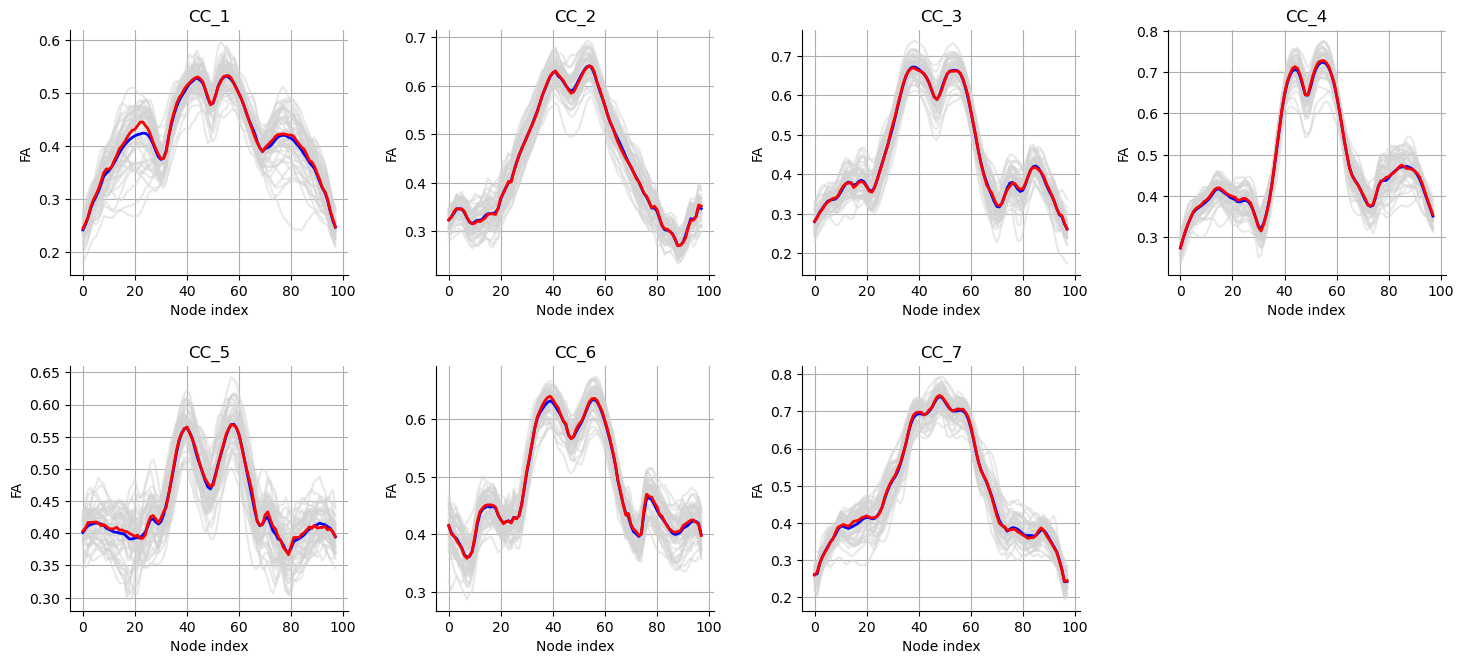

In [3]:
CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI_all[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI_all[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI_all[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel('FA')
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)



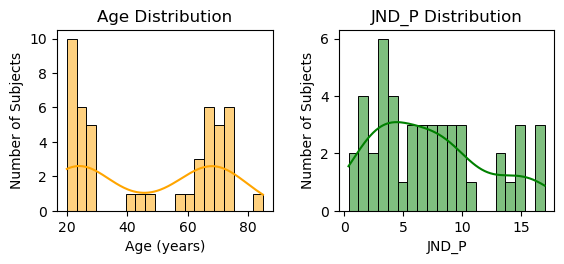

In [4]:
 # target var

import seaborn as sns

age_all = Aging_INDICES['age'].values
jnd_all = Aging_INDICES['JND_P'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age_all, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd_all, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, learning_curve
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, SelectFromModel
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.pipeline import Pipeline

labels = [0,1]

Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)
age_all_grouped = Aging_INDICES['group_O']
jnd_all_grouped = Aging_INDICES['JND_group']

Aging_INDICES

selection=age_all>0

# age=age_all[selection]
# jnd=jnd_all[selection]
# DTI=DTI_all[selection,:,:]

age=age_all[:42]
jnd=jnd_all[:42]
DTI=DTI_all[:42,:,:]


scaler=RobustScaler()
DTI_scaled=np.zeros_like(DTI)
for cc in range(7):
    d=scaler.fit_transform(DTI[:,:,cc])
    DTI_scaled[:,:,cc] = d

# scaler = RobustScaler()
# DTI_all_scaled = scaler.fit_transform(DTI.reshape(-1, DTI.shape[-1])).reshape(DTI.shape)

# DTI=DTI_all_scaled
DTI_scaled.shape

(42, 98, 7)

Feat selectio based on simple lin regression using f_regression

Feat selection based on simple linear regression using f_regression

CC 1 - Best features for JND: [76 75 77 84 74 85 83 86 82 78]
CC 1 - Best features for Age: [15 14 16 13 17 12 18 74 75 11]
CC 2 - Best features for JND: [13 87 72  7  9 73 70 69 71 86]
CC 2 - Best features for Age: [10 72  9 70 71 12 63 62 83 73]
CC 3 - Best features for JND: [14 13 22 15 23 12 21 24 67 68]
CC 3 - Best features for Age: [42 41 40 23 66 43 14 24 67 22]
CC 4 - Best features for JND: [70 69 71 57 78 56 45 77 79 54]
CC 4 - Best features for Age: [77 78 76 69 70 79  7  6 75 55]
CC 5 - Best features for JND: [74 73 15 16 58 59 42 75 60 72]
CC 5 - Best features for Age: [73 74 72 75 10 11 13 12 88  8]
CC 6 - Best features for JND: [75 84 52 86 85 87 82 83 51 88]
CC 6 - Best features for Age: [82 83 81 84 80 85 79 15 78 86]
CC 7 - Best features for JND: [41 42 53 40 38 43 54 37 39 52]
CC 7 - Best features for Age: [22 24 30 32 23  0 25 31 33 29]


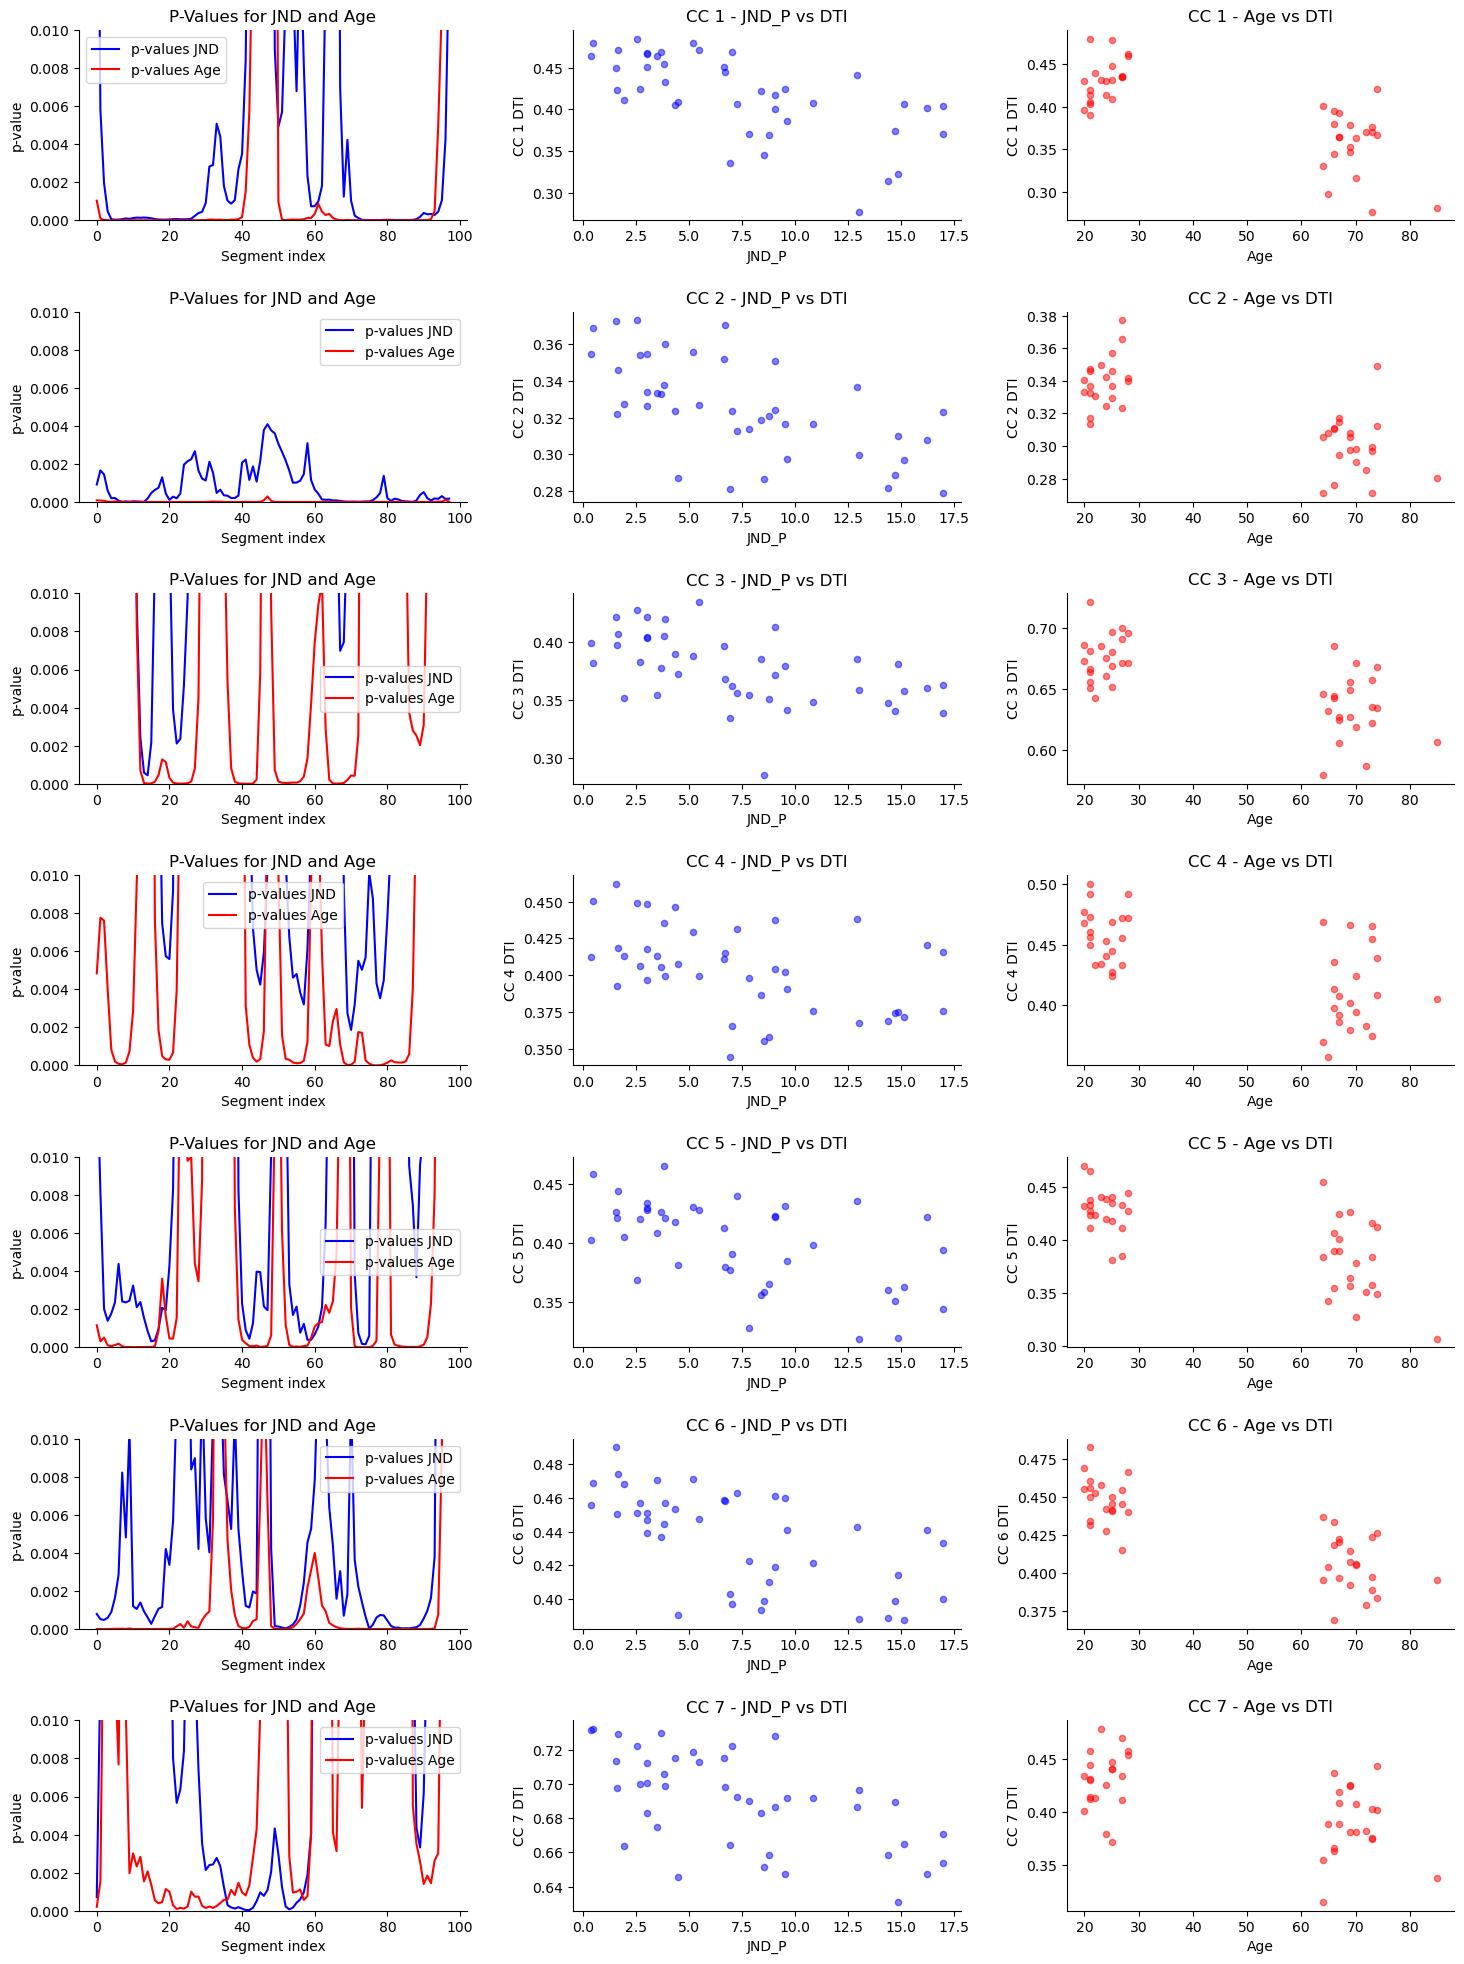

In [6]:
fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

f_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

print('Feat selection based on simple linear regression using f_regression\n')

for cc in range(1,8):
        
    f_statistic_jnd, p_values_jnd = f_regression(DTI[:,:,cc-1], jnd )
    f_statistic_age, p_values_age = f_regression(DTI[:,:,cc-1], age )

    f_reg_best_features_jnd_cc = np.argsort(p_values_jnd)[:97]
    f_reg_best_features_age_cc = np.argsort(p_values_age)[:97]
    
    print(f'CC {cc} - Best features for JND: {f_reg_best_features_jnd_cc[:10]}')
    print(f'CC {cc} - Best features for Age: {f_reg_best_features_age_cc[:10]}')

    f_reg_best_features_jnd_cc_allCC[cc-1,:]= f_reg_best_features_jnd_cc[:10]
    f_reg_best_features_age_cc_allCC[cc-1,:] = f_reg_best_features_age_cc[:10]

    axs[cc-1,0].plot(p_values_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(p_values_age, color='red', label='p-values Age')

    axs[cc-1,0].set_ylim(0, 0.01)
    axs[cc-1,0].set_xlabel('Segment index')
    axs[cc-1,0].set_ylabel('p-value')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('P-Values for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)


    featn_jnd=f_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=f_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    
plt.tight_layout(pad=2.0)



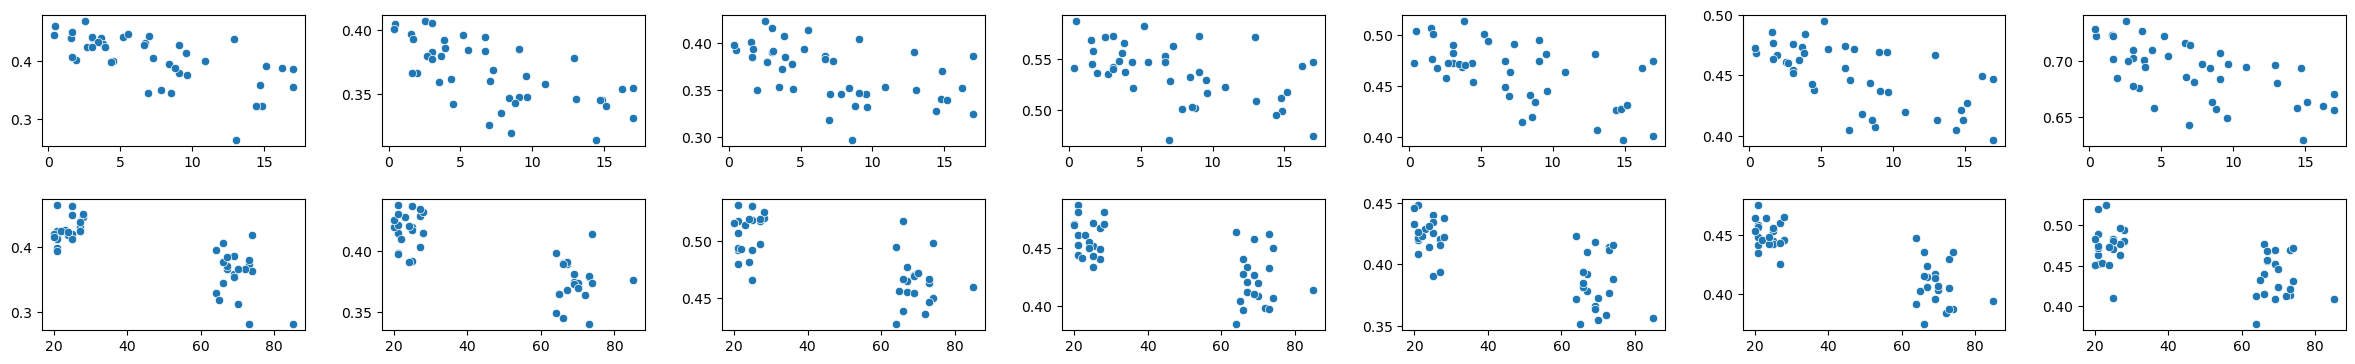

In [7]:
fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,4))

for cc in range(7):
    sns.scatterplot(y=DTI[:,f_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc]) 
    sns.scatterplot(y=DTI[:,f_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc])

plt.tight_layout(pad=2.0)

feat selection based on mutual_info_regression

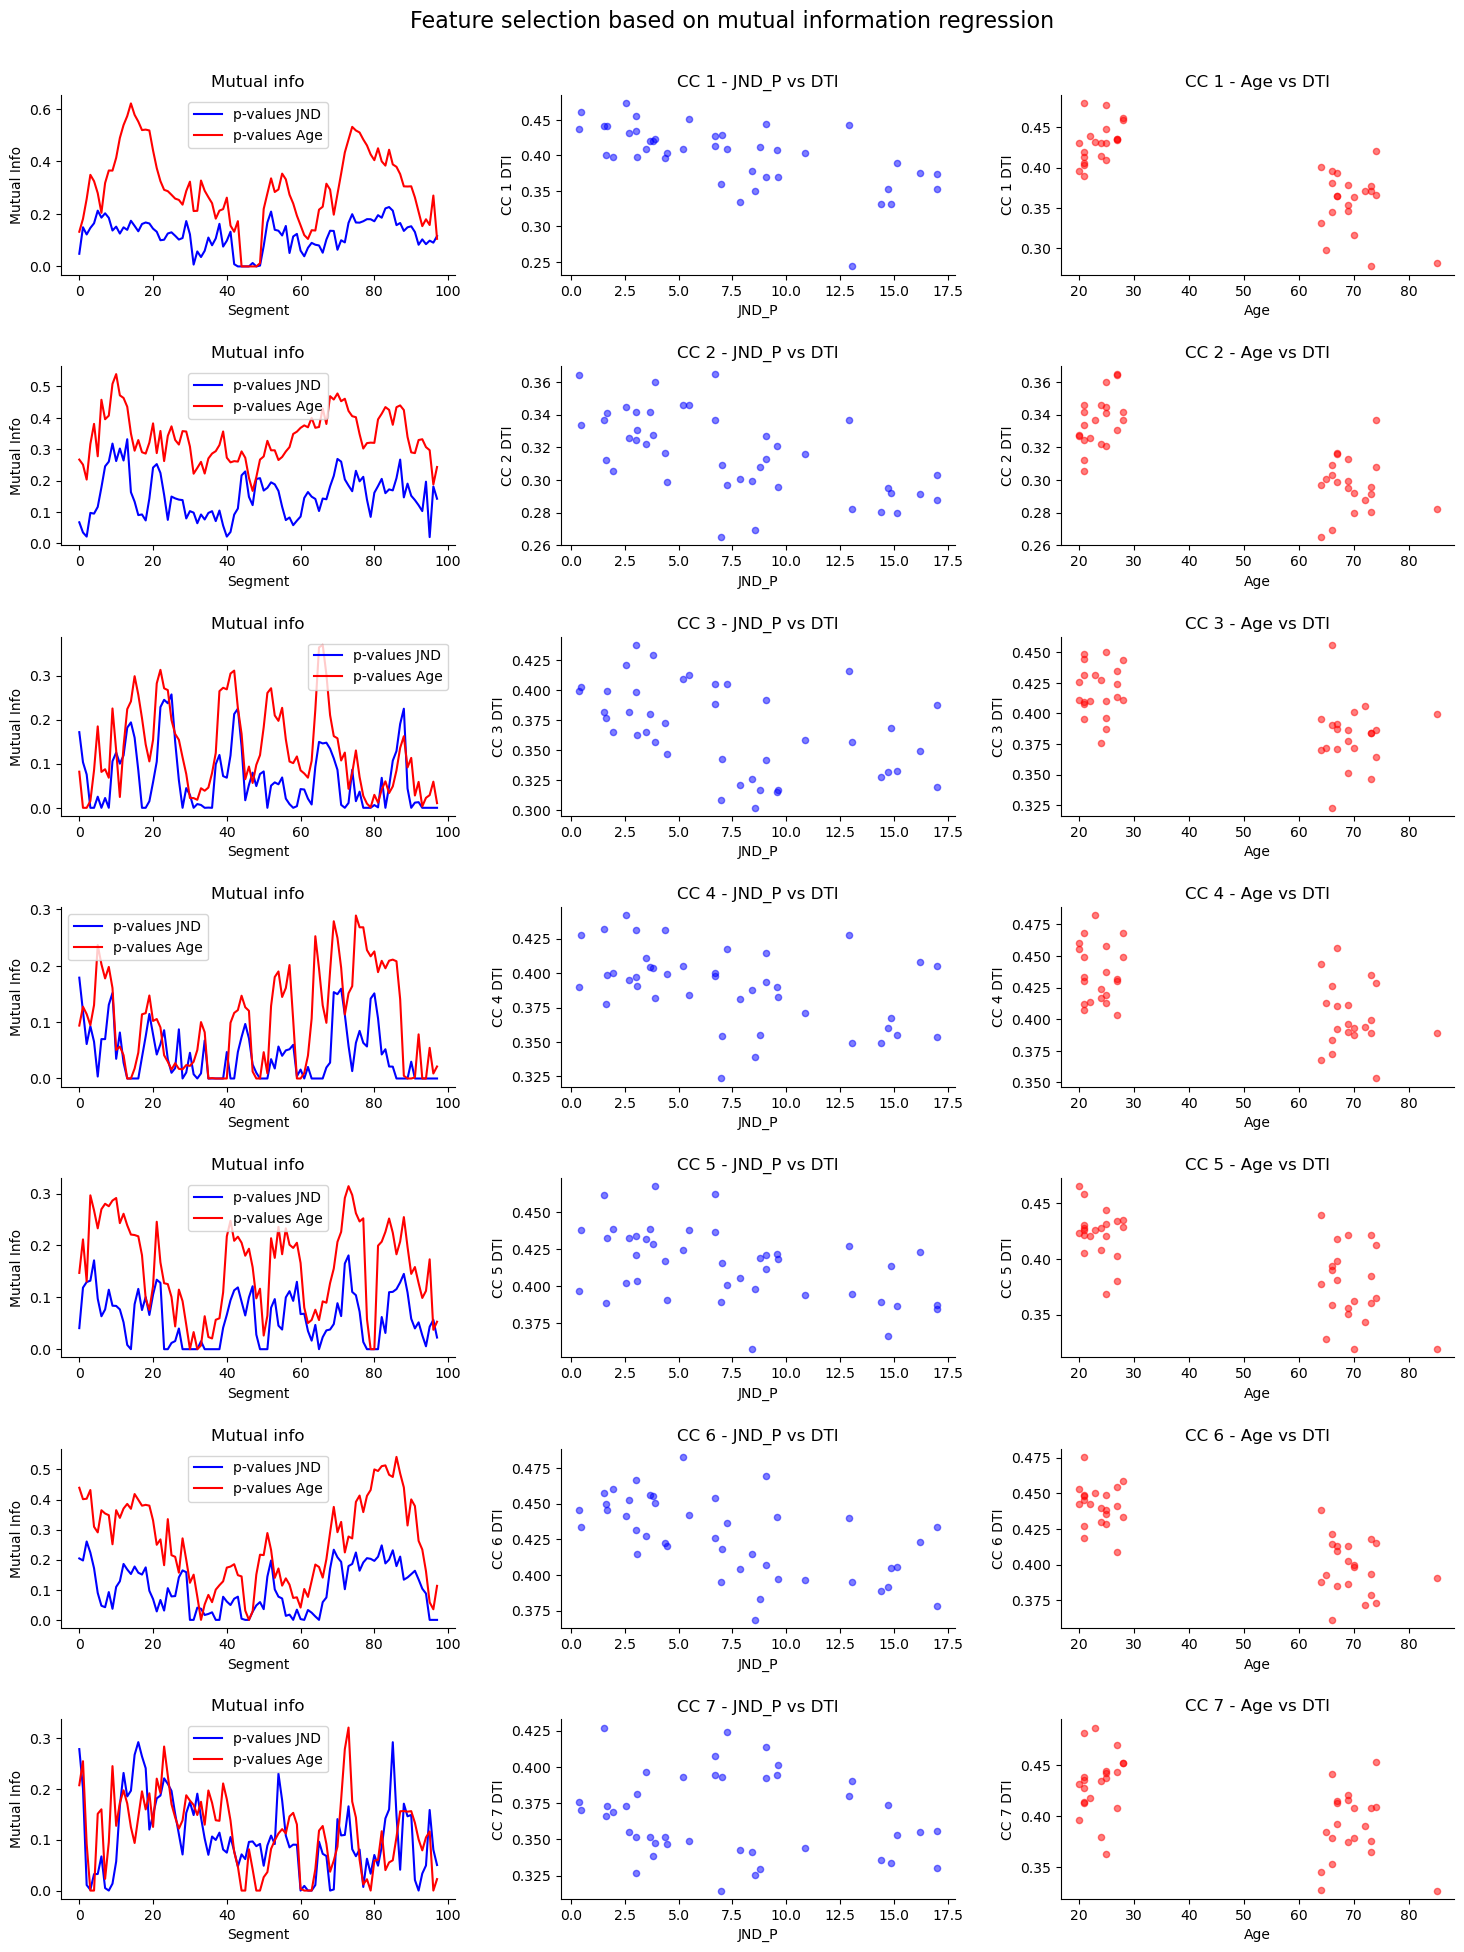

In [8]:
from sklearn.feature_selection import mutual_info_regression

fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

mutual_info_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
mutual_info_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

mutual_info_age_allcc = np.zeros((7,98))
mutual_info_jnd_allcc = np.zeros((7,98))

for cc in range(1,8):   

    mutual_info_jnd = mutual_info_regression(DTI[:,:,cc-1], jnd, discrete_features=False,n_neighbors=6)
    mutual_info_age = mutual_info_regression(DTI[:,:,cc-1], age, discrete_features=False,n_neighbors=6)

    mutual_info_age_allcc[cc-1,:] = mutual_info_age
    mutual_info_jnd_allcc[cc-1,:] = mutual_info_jnd

    mutual_info_best_features_jnd_cc = np.argsort(mutual_info_jnd)[:97]
    mutual_info_best_features_age_cc = np.argsort(mutual_info_age)[:97]

    mutual_info_best_features_jnd_cc_allCC[cc-1,:]= mutual_info_best_features_jnd_cc[-10:]
    mutual_info_best_features_age_cc_allCC[cc-1,:] = mutual_info_best_features_age_cc[-10:]


    axs[cc-1,0].plot(mutual_info_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(mutual_info_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Mutual Info')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Mutual info')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=mutual_info_best_features_jnd_cc[-1]  # on prend la feature la plus significative pour JND
    featn_age=mutual_info_best_features_age_cc[-1]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')

fig.suptitle('Feature selection based on mutual information regression\n', fontsize=16)

plt.tight_layout(pad=2.0) 

based on r_regression

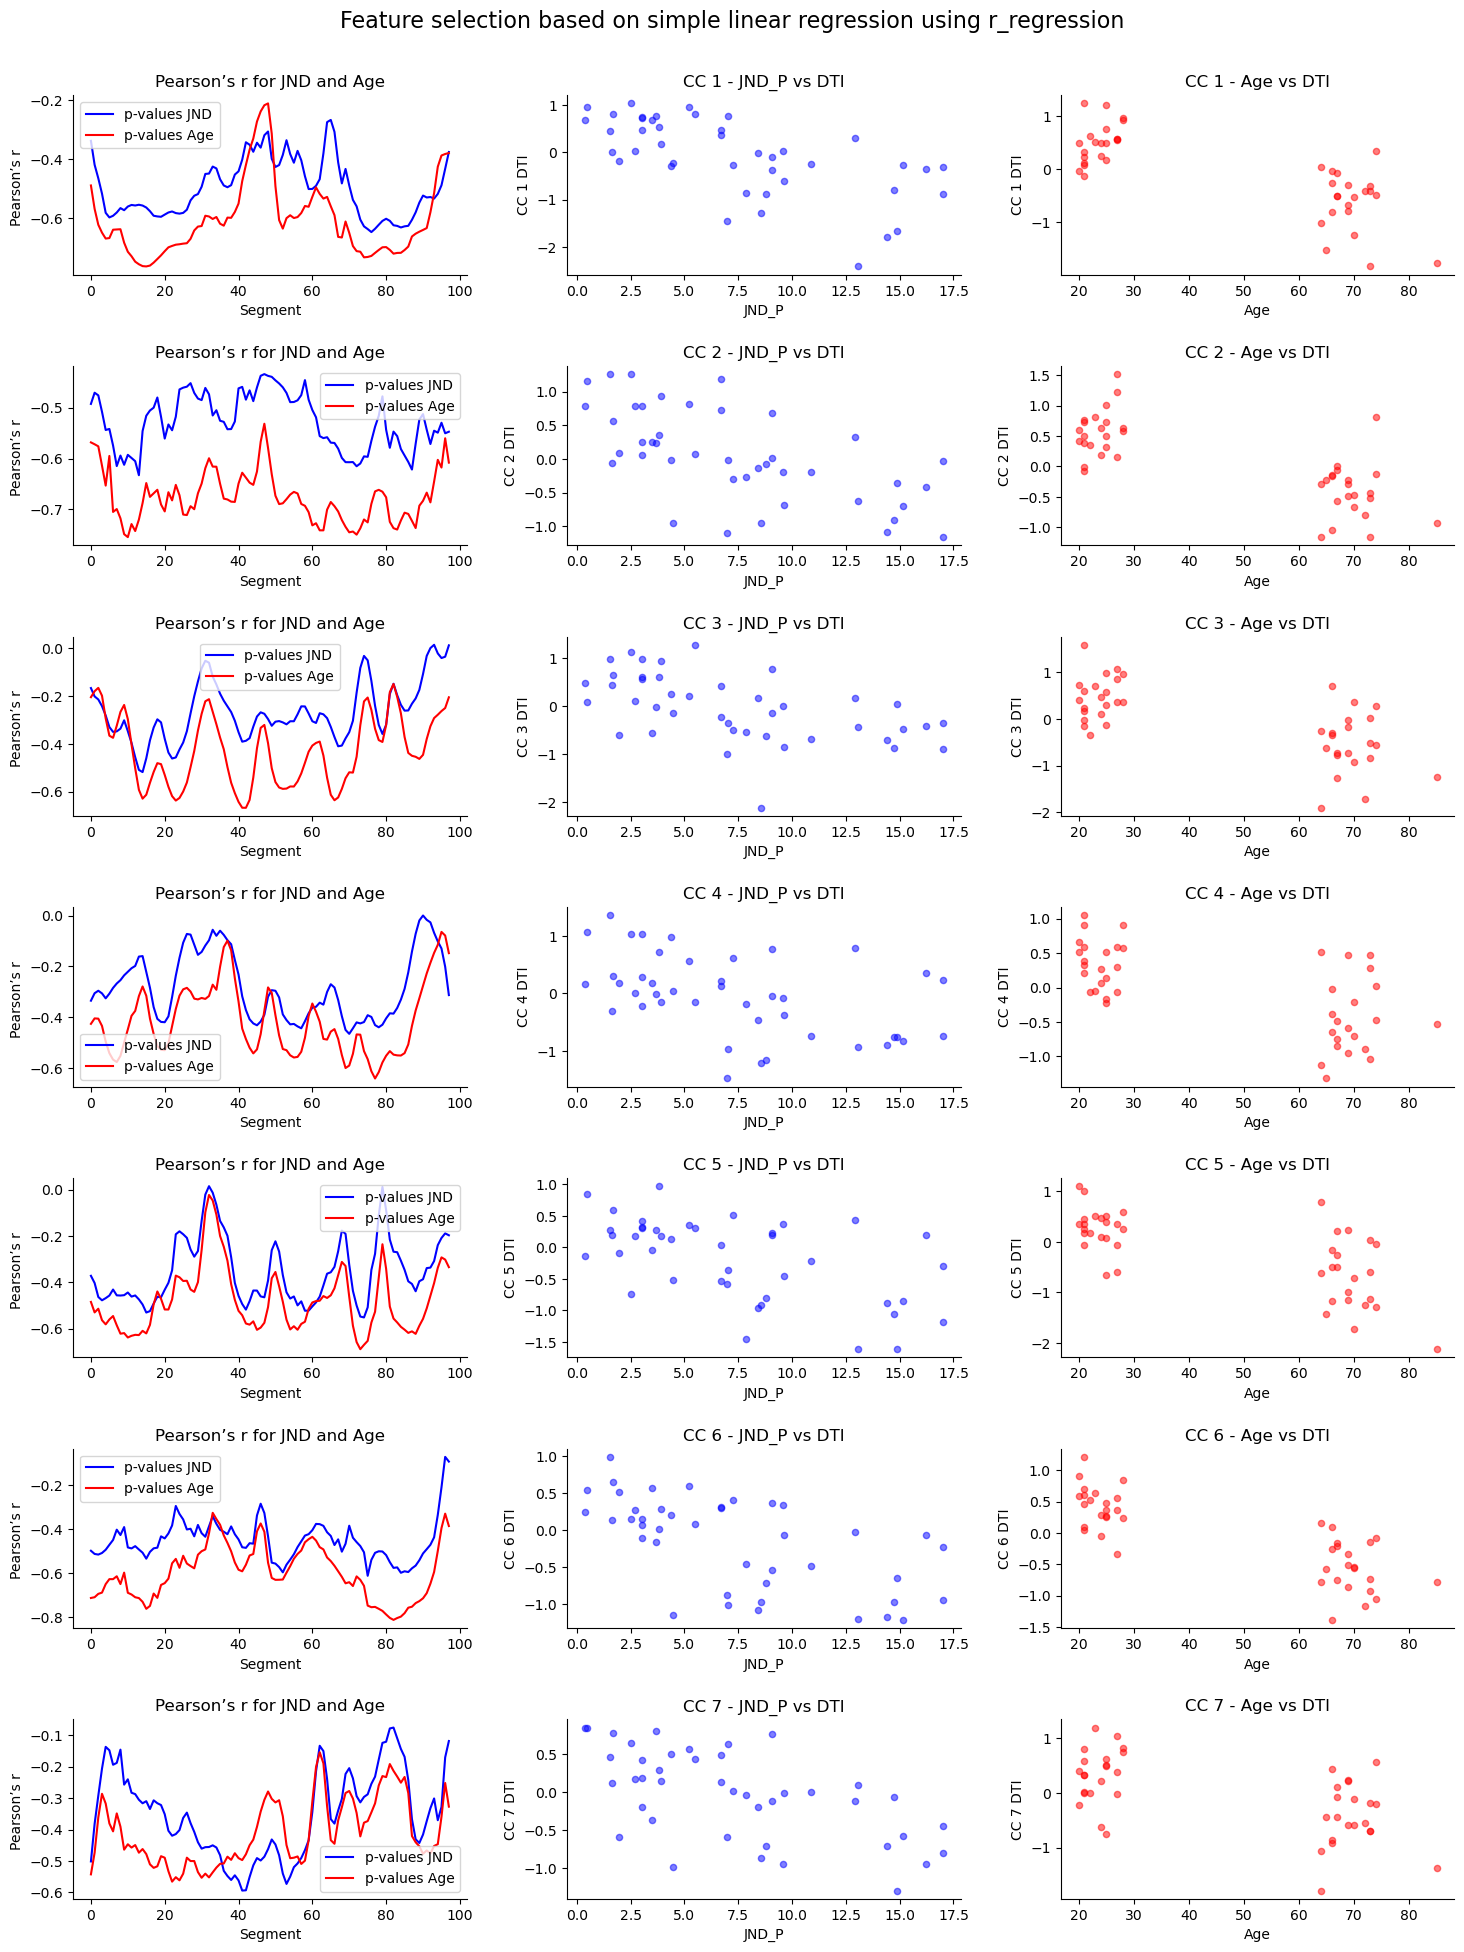

In [74]:
from sklearn.feature_selection import r_regression






####

from sklearn.feature_selection import r_regression

fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

r_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

r_reg_age_allcc = np.zeros((7,98))
for cc in range(1,8):   

    r_reg_jnd = r_regression(DTI_scaled[:,:,cc-1], jnd)
    r_reg_age = r_regression(DTI_scaled[:,:,cc-1], age)

    r_reg_age_allcc[cc-1,:] = r_reg_age
    
    r_reg_best_features_jnd_cc = np.argsort(r_reg_jnd)[:97]
    r_reg_best_features_age_cc = np.argsort(r_reg_age)[:97]

    r_reg_best_features_jnd_cc_allCC[cc-1,:]= r_reg_best_features_jnd_cc[:10]
    r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[:10]


    axs[cc-1,0].plot(r_reg_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Pearson’s r ')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Pearson’s r for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=r_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=r_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')

fig.suptitle('Feature selection based on simple linear regression using r_regression\n', fontsize=16)
    
plt.tight_layout(pad=2.0) 

In [10]:
r_reg_best_features_age_cc_allCC[6]

array([22, 24, 30, 32, 23,  0, 25, 31, 33, 29])

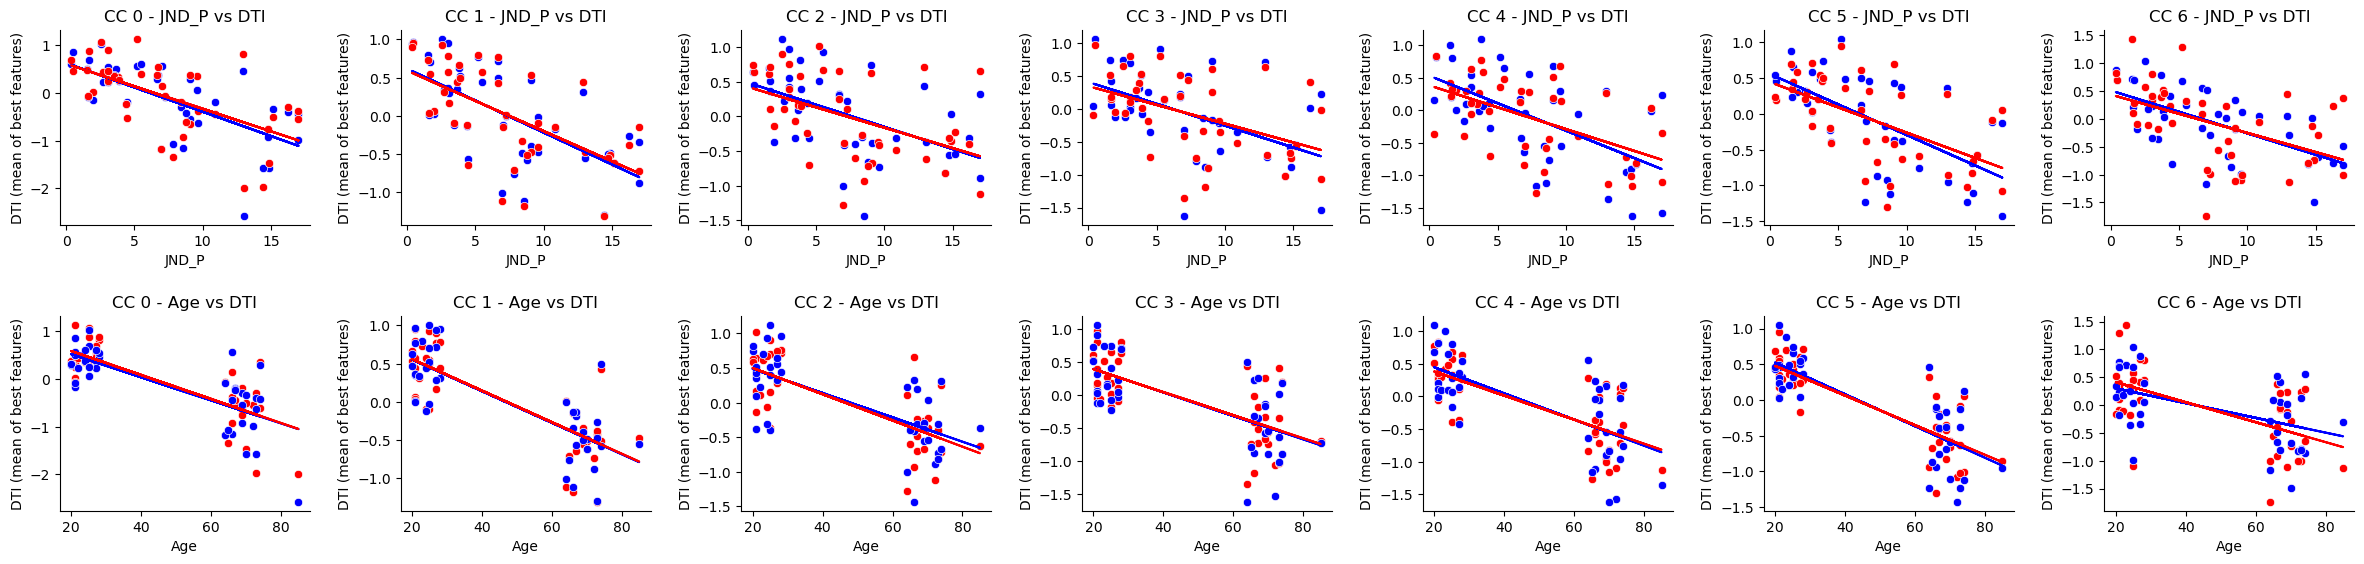

In [84]:
import statsmodels.api as sm
 

fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,6))

for cc in range(7):

    x = sm.add_constant(jnd)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2


    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='blue')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='red') 
    axs[0,cc].set_title(f'CC {cc} - JND_P vs DTI')
    axs[0,cc].spines['top'].set_visible(False)
    axs[0,cc].spines['right'].set_visible(False)
    axs[0,cc].set_xlabel('JND_P')
    axs[0,cc].set_ylabel('DTI (mean of best features)')
    # Tracer la ligne de régression
    axs[0,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[0,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')



    
    x = sm.add_constant(age)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='red')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='blue')
    axs[1,cc].set_title(f'CC {cc} - Age vs DTI')
    axs[1,cc].spines['top'].set_visible(False)
    axs[1,cc].spines['right'].set_visible(False)
    axs[1,cc].set_xlabel('Age')
    axs[1,cc].set_ylabel('DTI (mean of best features)')
    axs[1,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[1,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')

plt.tight_layout(pad=2.0)



       


Regression prediction test on cc 7 best feat

[22 24 30 32 23  0 25 31 33 29]
[41 42 53 40 38 43 54 37 39 52]
Mean MSE for JND: 25.2422 ± 9.4792
Mean MSE for Age: 25.0350 ± 9.5916
P-value from independent t-test: 0.8786
Mean R² for JND: -0.2273 ± 0.6336
Mean R² for Age: -0.2097 ± 0.6299
P-value from independent t-test: 0.8449
Mean MAE for JND: 4.1370 ± 0.8599
Mean MAE for Age: 4.0635 ±   0.8706
P-value from independent t-test: 0.5508


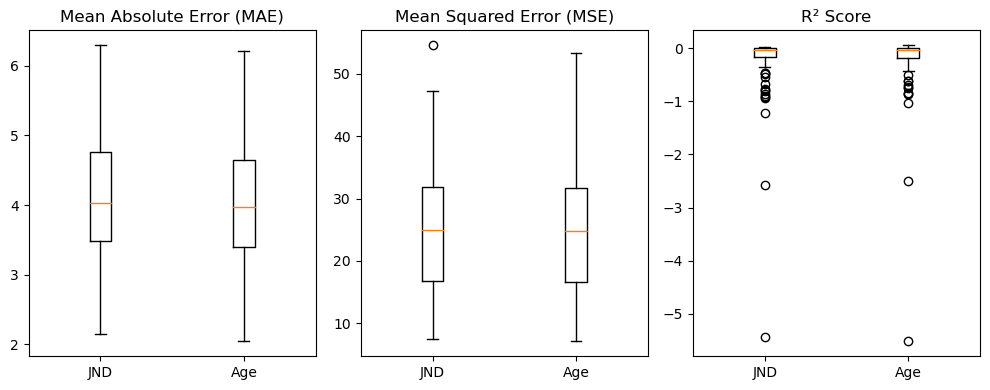

In [12]:
cc=6
print(r_reg_best_features_age_cc_allCC[cc])
print(r_reg_best_features_jnd_cc_allCC[cc])

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_rel as t_test_rel, ttest_ind as t_test_ind

mae_jnd_rd = []
mae_age_rd = []
mse_jnd_rd = []
mse_age_rd = []
r2_jnd_rd = []
r2_age_rd = []

for rd in range(100):

    X_train,X_test,y_train,y_test=train_test_split(DTI[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc], jnd, test_size=0.2, random_state=rd)
    regr=svm.SVR(kernel='linear')
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)
    regr.score(X_test, y_test)

    mae_jnd_rd.append(mean_absolute_error(y_test, y_pred))
    mse_jnd_rd.append(mean_squared_error(y_test, y_pred))
    r2_jnd_rd.append(r2_score(y_test, y_pred))

    X_train,X_test,y_train,y_test=train_test_split(DTI[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc], jnd, test_size=0.2, random_state=rd)
    regr=svm.SVR(kernel='linear')
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)
    regr.score(X_test, y_test)
  
    mae_age_rd.append(mean_absolute_error(y_test, y_pred))
    mse_age_rd.append(mean_squared_error(y_test, y_pred))
    r2_age_rd.append(r2_score(y_test, y_pred))




fig,ax=plt.subplots(nrows=1, ncols=3,figsize=(10,4))
ax[0].boxplot([mae_jnd_rd, mae_age_rd], labels=['JND', 'Age'])
ax[0].set_title('Mean Absolute Error (MAE)')
ax[1].boxplot([mse_jnd_rd, mse_age_rd], labels=['JND', 'Age'])
ax[1].set_title('Mean Squared Error (MSE)')
ax[2].boxplot([r2_jnd_rd, r2_age_rd], labels=['JND', 'Age'])
ax[2].set_title('R² Score')
plt.tight_layout()

t,pvalue=t_test_ind(mse_jnd_rd, mse_age_rd)
print(f'Mean MSE for JND: {np.mean(mse_jnd_rd):.4f} ± {np.std(mse_jnd_rd):.4f}')
print(f'Mean MSE for Age: {np.mean(mse_age_rd):.4f} ± {np.std(mse_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

t,pvalue=t_test_ind(r2_jnd_rd, r2_age_rd)
print(f'Mean R² for JND: {np.mean(r2_jnd_rd):.4f} ± {np.std(r2_jnd_rd):.4f}')
print(f'Mean R² for Age: {np.mean(r2_age_rd):.4f} ± {np.std(r2_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

t,pvalue=t_test_ind(mae_jnd_rd, mae_age_rd)
print(f'Mean MAE for JND: {np.mean(mae_jnd_rd):.4f} ± {np.std(mae_jnd_rd):.4f}')
print(f'Mean MAE for Age: {np.mean(mae_age_rd):.4f} ±   {np.std(mae_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

In [134]:


DTI_JND=pd.DataFrame([])
DTI_AGE=pd.DataFrame([])
for cc in range(1,8):
    DTI_JND_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc-1],cc-1])
    DTI_JND_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_jnd_cc_allCC[cc-1]]
    DTI_JND=pd.concat([DTI_JND, DTI_JND_tmp], axis=1)

    DTI_AGE_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc-1],cc-1])
    DTI_AGE_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_age_cc_allCC[cc-1]]
    DTI_AGE=pd.concat([DTI_AGE, DTI_AGE_tmp], axis=1)

print(r_reg_best_features_jnd_cc_allCC)
print(r_reg_best_features_age_cc_allCC)


DTI_JND.describe()
DTI_JND

[[76 75 77 84 74 85 83 86 82 78]
 [13 87 72  7  9 73 70 69 71 86]
 [14 13 22 15 23 12 21 24 67 68]
 [70 69 71 57 78 56 45 77 79 54]
 [74 73 15 16 58 59 42 75 60 72]
 [75 84 52 86 85 87 82 83 51 88]
 [41 42 53 40 38 43 54 37 39 52]]
[[15 14 16 13 17 12 18 74 75 11]
 [10 72  9 70 71 12 63 62 83 73]
 [42 41 40 23 66 43 14 24 67 22]
 [77 78 76 69 70 79  7  6 75 55]
 [73 74 72 75 10 11 13 12 88  8]
 [82 83 81 84 80 85 79 15 78 86]
 [22 24 30 32 23  0 25 31 33 29]]


,CC1_76,CC1_75,CC1_77,CC1_84,CC1_74,CC1_85,CC1_83,CC1_86,CC1_82,CC1_78,...,CC7_41,CC7_42,CC7_53,CC7_40,CC7_38,CC7_43,CC7_54,CC7_37,CC7_39,CC7_52
0,0.033724,0.045549,0.102387,-0.074132,0.108268,0.035155,-0.006562,0.266805,0.029855,0.120890,...,-0.952250,-0.840794,-0.594393,-1.214158,-1.464917,-0.724022,-0.750900,-1.450780,-1.379767,-0.518687
1,0.359143,0.552264,0.263217,0.440564,0.505952,0.437720,0.325048,0.551741,0.175616,0.139782,...,0.129658,0.303941,-0.122652,-0.035761,-0.585915,0.102857,-0.251767,-0.690616,-0.325523,-0.148394
2,0.304436,0.402427,0.315608,0.556547,0.272523,0.585256,0.604745,0.635465,0.648732,0.384652,...,-0.123713,-0.297966,-0.009732,0.126060,0.233977,0.101435,-0.337880,0.325897,0.275867,0.294702
3,-0.189268,-0.188843,-0.231340,-0.157421,-0.203670,-0.110637,-0.185337,0.074080,-0.195996,-0.181481,...,-0.600206,-0.494098,0.568581,-0.626186,-0.268969,-0.096934,-0.121310,-0.247306,-0.444801,0.602121
4,1.034589,1.091419,1.058936,0.992583,1.066837,0.880240,1.153508,0.911265,1.129466,1.074719,...,0.638545,1.064109,1.627207,0.514826,0.875844,1.559221,0.946278,0.834528,0.784208,1.497575
5,-0.228904,-0.400091,-0.151506,-0.149680,-0.506801,-0.224699,-0.076952,-0.164117,0.019846,0.039817,...,-0.984215,-1.287976,-0.420449,-0.877081,-0.876201,-1.178794,-0.738729,-0.702773,-0.815776,-0.280496
6,-0.605149,-0.609714,-0.680040,-0.645846,-0.577281,-0.638700,-0.679043,-0.474844,-0.658233,-0.691709,...,-0.013731,0.195500,0.567387,-0.080156,-0.244867,0.574106,-0.271338,-0.278542,-0.057737,0.861676
7,-0.271575,-0.298776,-0.295971,0.103308,-0.287204,0.233208,0.014292,0.337122,-0.068903,-0.328358,...,0.005705,0.001184,-0.977712,0.042120,-0.196015,-0.013806,-0.588411,-0.471127,0.134247,-0.858554
8,0.015977,0.017122,0.005812,-0.165276,0.132819,-0.320363,-0.138669,-0.308439,-0.009184,-0.014026,...,0.113236,0.436406,0.392439,-0.023088,0.071707,0.549884,0.092605,0.112184,-0.015752,0.424274
9,0.768235,0.801808,0.807939,0.145473,0.771519,0.126294,0.215533,0.149066,0.401534,0.795171,...,0.800894,0.825421,0.798392,0.841940,0.844318,0.750546,0.790859,0.698174,0.891817,0.566290


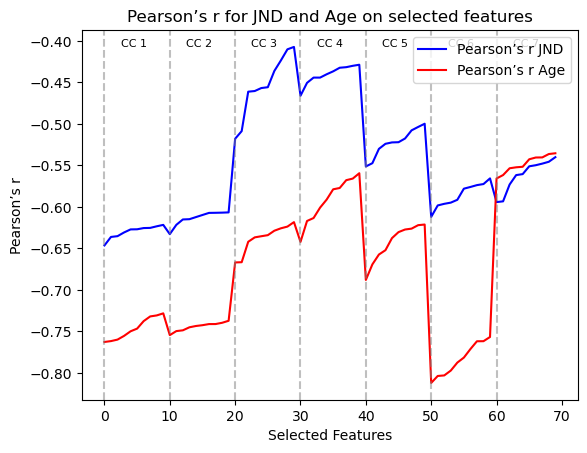

In [135]:
cc=1
r_reg_jnd70 = r_regression(DTI_JND, jnd)
r_reg_age70 = r_regression(DTI_AGE, age)


plt.plot(r_reg_jnd70, color='blue', label='Pearson’s r JND')
plt.plot(r_reg_age70, color='red', label='Pearson’s r Age')
plt.xlabel('Selected Features')
plt.ylabel('Pearson’s r')
plt.title('Pearson’s r for JND and Age on selected features')
plt.legend()

for i in range(7):
    plt.axvline(x=i*10, color='gray', linestyle='--', alpha=0.5)
    plt.text(i*10 + 2.5, max(max(r_reg_jnd70), max(r_reg_age70)), f'CC {i+1}', color='black', fontsize=8)


<Axes: >

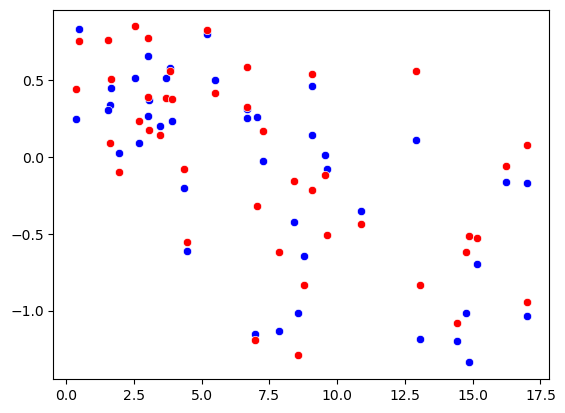

In [136]:
from sklearn.feature_selection import SequentialFeatureSelector

X=DTI_JND
y=jnd
sfs = SequentialFeatureSelector(estimator=svm.SVR(kernel='linear'), n_features_to_select=10, direction='forward')
sfs.fit(X, y)
X10=sfs.transform(X)

sns.scatterplot(x=y, y=X10.mean(axis=1), color='blue')


X=DTI_AGE
y=jnd
sfs = SequentialFeatureSelector(estimator=svm.SVR(kernel='linear'), n_features_to_select=10, direction='forward')
sfs.fit(X, y)
X10=sfs.transform(X)

sns.scatterplot(x=y, y=X10.mean(axis=1), color='red')


In [137]:
Aging_INDICES['JND_group3'] = pd.qcut(Aging_INDICES['JND_P'], q=3, labels=[0,1,2])
Aging_INDICES['JND_group3']

0     2
1     1
2     2
3     0
4     0
5     1
6     2
7     1
8     0
9     0
10    0
11    0
12    2
13    2
14    2
15    1
16    0
17    0
18    2
19    1
20    0
21    2
22    2
23    0
24    0
25    2
26    0
27    2
28    1
29    0
30    1
31    1
32    0
33    1
34    1
35    0
36    2
37    1
38    2
39    2
40    2
41    1
42    0
43    2
44    1
45    1
46    1
Name: JND_group3, dtype: category
Categories (3, int64): [0 < 1 < 2]

JND_group
0    24
1    23
Name: count, dtype: int64
T-test JND group: t=6.2084, p=0.0000
T-test JND group: t=6.3494, p=0.0000
T-test Age group: t=7.5967, p=0.0000
T-test Age group: t=9.0166, p=0.0000


(42, 70)

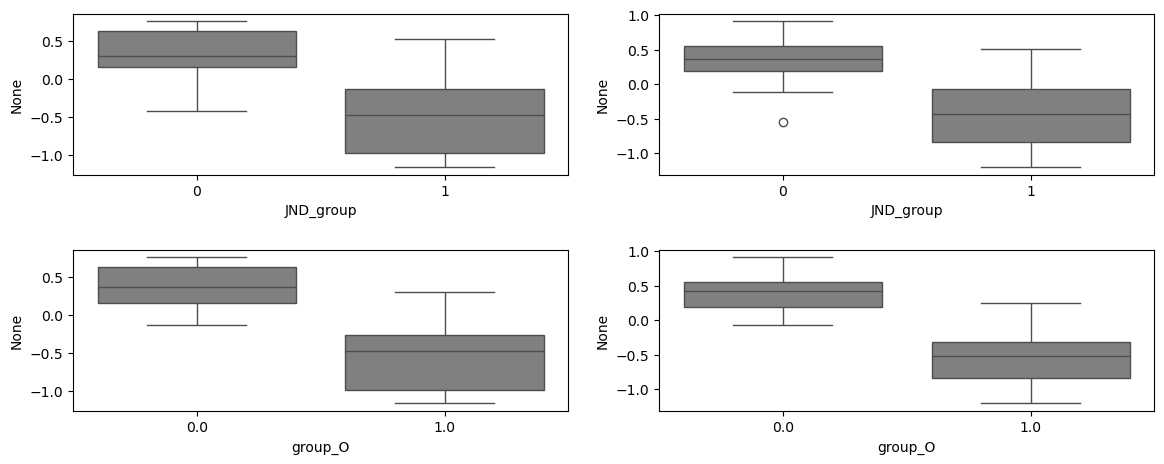

In [138]:


fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['JND_group'], color='grey', ax=axs[0,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['JND_group'], color='grey', ax=axs[0,1])
print(Aging_INDICES['JND_group'].value_counts())
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,1])
plt.tight_layout(pad=2.0)

t,pval=t_test_ind(DTI_JND.mean(axis=1)[Aging_INDICES['JND_group']==0], DTI_JND.mean(axis=1)[Aging_INDICES['JND_group']==1])
print(f'T-test JND group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_AGE.mean(axis=1)[Aging_INDICES['JND_group']==0], DTI_AGE.mean(axis=1)[Aging_INDICES['JND_group']==1])
print(f'T-test JND group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_JND.mean(axis=1)[Aging_INDICES['group_O']==0], DTI_JND.mean(axis=1)[Aging_INDICES['group_O']==1])
print(f'T-test Age group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_AGE.mean(axis=1)[Aging_INDICES['group_O']==0], DTI_AGE.mean(axis=1)[Aging_INDICES['group_O']==1])
print(f'T-test Age group: t={t:.4f}, p={pval:.4f}')
DTI_JND.shape

JND_group3
0    16
2    16
1    15
Name: count, dtype: int64


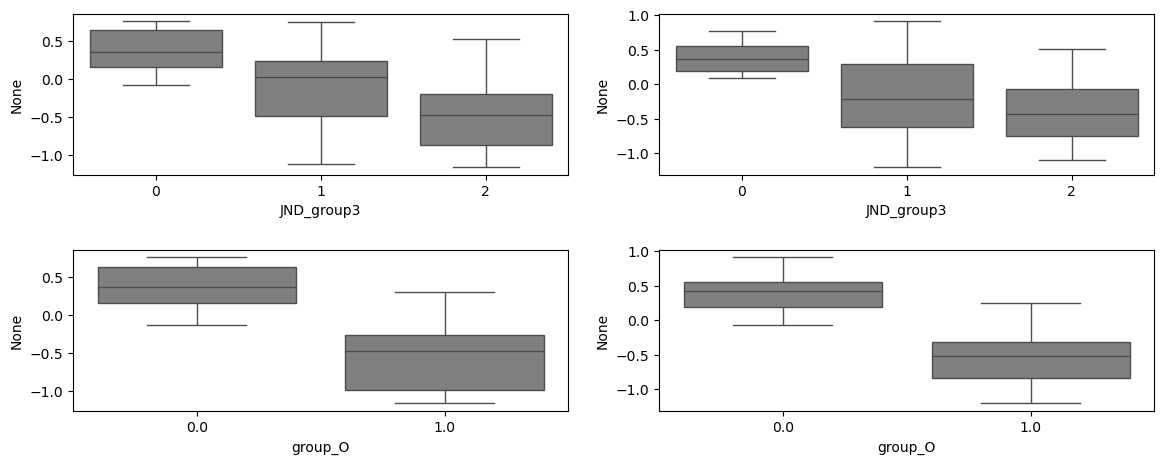

In [139]:


fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['JND_group3'], color='grey', ax=axs[0,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['JND_group3'], color='grey', ax=axs[0,1])
print(Aging_INDICES['JND_group3'].value_counts())
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,1])
plt.tight_layout(pad=2.0)



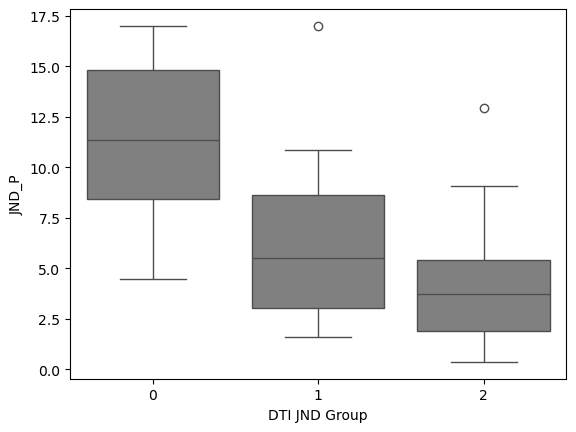

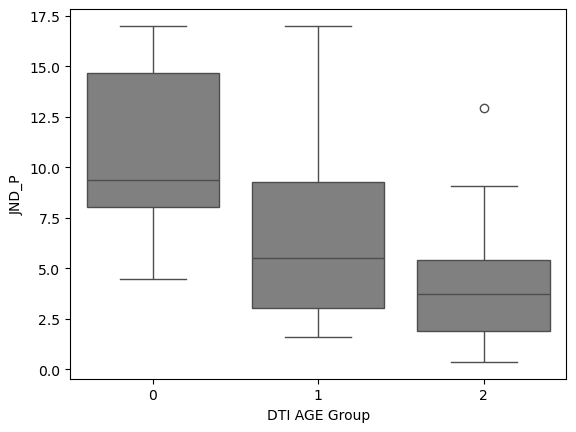

In [150]:
DTI_3g_JND = pd.qcut(DTI_JND.mean(axis=1), q=3, labels=[0,1,2])
DTI_3g_AGE = pd.qcut(DTI_AGE.mean(axis=1), q=3, labels=[0,1,2])

sns.boxplot(y=jnd,x=DTI_3g_JND,color='grey')
plt.xlabel('DTI JND Group')
plt.ylabel('JND_P')
plt.show()
sns.boxplot(y=jnd,x=DTI_3g_AGE,color='grey')
plt.xlabel('DTI AGE Group')
plt.ylabel('JND_P')
plt.show()
